[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Advanced-Time-Series/blob/main/Quantlets/Ch_09/ATS_ch9_seminar/ATS_ch9_seminar.ipynb)

# Advanced Time Series Analysis and Forecasting — Seminar 9: VaR, ES and backtesting

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- The seminar comes before Lecture 9; the slides give the definitions ("What you need today").
- [Solved] tasks: full solution here and in the slides; [Proposed] tasks: write your own code in the empty cell.
- The seminar is for practice and is not graded; the solutions of [Proposed] tasks are discussed in class.

> Quantlet `ATS_ch9_seminar`: student version of the Seminar 9 notebook. Solved exercises (A1, A3, A5, A7, B1, B3, B5) are shown with code and output; the proposed exercises (A2, A4, A6, A8, B2, B4, B6, C1, C2) are not solved here (an empty code cell where they need code).

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/ATS/Chapter_9'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [ ]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import ats_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the ATS repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Advanced-Time-Series/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the ATS repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Seminar functions

- The numpy engine of Chapter 9, the data helpers and the functions of the solved tasks.

In [ ]:
import pickle
from scipy import special, integrate
try:                                    # numba accelerates the recursions; without it the code runs in plain Python
    from numba import njit as _njit

    def njit(*args, **kw):
        kw.pop('cache', None)           # no on-disk cache for functions defined in a notebook
        return _njit(*args, **kw)
except ImportError:
    def njit(*args, **kw):
        if args and callable(args[0]):
            return args[0]
        return lambda f: f
SEED = 2026
END = '2026-09-18'
ASSETS = {'sp500': ('1990-01-01', '2000-01-01'), 'dax': ('1990-01-01', '2000-01-01'), 'bet': ('2000-01-01', '2010-01-01'), 'eurron': ('2005-07-01', '2015-07-01'), 'btc': ('2014-09-17', '2020-01-01')}
LAB = {'sp500': 'S&P 500', 'dax': 'DAX', 'bet': 'BET', 'eurron': 'EUR/RON', 'btc': 'Bitcoin'}
MODELS = ['RW-125', 'RW-250', 'RW-500', 'GCH-N', 'GCH-Skt', 'GCH-EDF', 'FZ-2F', 'FZ-1F', 'GCH-FZ', 'Hybrid']
FZ_NAMES = ['FZ-2F', 'FZ-1F', 'GCH-FZ', 'Hybrid']
STRESS = {'2008': ('2008-09-01', '2009-03-31'), '2020': ('2020-02-19', '2020-06-30'), '2022': ('2022-01-03', '2022-12-30'), '2025': ('2025-03-03', '2025-06-30')}
PZC_TABLE = {0.05: {'RW-125': 0.914, 'RW-250': 0.959, 'RW-500': 1.023, 'GCH-N': 0.876, 'GCH-Skt': 0.866, 'GCH-EDF': 0.862, 'FZ-2F': 0.856, 'FZ-1F': 0.853, 'GCH-FZ': 0.862, 'Hybrid': 0.869}, 0.025: {'RW-125': 1.119, 'RW-250': 1.164, 'RW-500': 1.245, 'GCH-N': 1.089, 'GCH-Skt': 1.043, 'GCH-EDF': 1.028, 'FZ-2F': 1.041, 'FZ-1F': 1.032, 'GCH-FZ': 1.02, 'Hybrid': 1.034}}
PZC_GOF = {0.05: {'RW-125': (0.021, 0.029), 'RW-250': (0.001, 0.043), 'RW-500': (0.001, 0.012), 'GCH-N': (0.031, 0.001), 'GCH-Skt': (0.003, 0.003), 'GCH-EDF': (0.003, 0.014), 'FZ-2F': (0.0, 0.061), 'FZ-1F': (0.242, 0.313), 'GCH-FZ': (0.005, 0.018), 'Hybrid': (0.001, 0.01)}}
EM_DESIGN = {'n_in': 2892, 'n_out': 500}
CACHE = ''
_MEM = {}
CAVIAR_K = {'SAV': 3, 'AS': 4, 'IG': 3, 'ADAPT': 1}
SPEC_ID = {'SAV': 0, 'AS': 1, 'IG': 2, 'ADAPT': 3}
FZ_MODELS = {'FZ-2F': 0, 'FZ-1F': 1, 'GCH-FZ': 2, 'Hybrid': 3}
FZ_NPAR = {0: 8, 1: 4, 2: 4, 3: 5}
A1 = {'y': [-3.1, -1.2, -0.4, 0.3, 0.9, 1.5, 2.2, -2.0, 0.1, 0.6], 'a': 0.1, 'xs': [-3.1, -2.6, -2.0, -1.2]}
A3 = {'a': 0.025, 'ys': [-3.0, 0.5], 'f1': (-1.96, -2.34), 'f2': (-2.5, -3.2)}
A4 = {'d': [3, 41, 2, 160, 95, 1, 4, 230, 12, 2, 68, 7], 'a': 0.01}
A5 = {'omega': 0.02, 'alpha': 0.08, 'beta': 0.9, 'h': (4.0, 0.5), 'H': 10, 'a': 0.01}
A6 = {'sav': (0.36, 0.7, 0.6), 'as_': (0.26, 0.81, 0.04, 0.62), 'var0': 2.0, 'y': (-3.0, 1.0)}
A7 = {'T': 250, 'a': 0.025, 'L': [3.9, 2.8, 4.6, 3.1, 6.2, 2.9, 3.4], 'VaR': [2.6, 2.5, 2.9, 2.7, 3.0, 2.6, 2.8], 'ES': [3.3, 3.1, 3.6, 3.4, 3.8, 3.2, 3.5], 'sig': [1.2, 1.1, 1.3, 1.2, 1.4, 1.15, 1.25]}
A8 = {'models': ['A', 'B', 'C'], 'dm': [-2.31, 0.84, 2.05]}


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def returns(name, start=None, end=END):
    """Daily log returns in % (EUR/RON: BNR reference rate; Bitcoin: 7 days a week)."""
    s = ASSETS[name][0] if start is None else start
    return log_returns(name, start=s, end=end).dropna()


def cached(key, fn):
    """Results of the expensive steps, kept in memory (and in a pickle if ATS_CH9_CACHE is set)."""
    if key in _MEM:
        return _MEM[key]
    if CACHE:
        p = os.path.join(CACHE, f'ch9_{key}.pkl')
        if os.path.exists(p):
            _MEM[key] = pickle.load(open(p, 'rb'))
            return _MEM[key]
    _MEM[key] = fn()
    if CACHE:
        os.makedirs(CACHE, exist_ok=True)
        pickle.dump(_MEM[key], open(os.path.join(CACHE, f'ch9_{key}.pkl'), 'wb'))
    return _MEM[key]


def shade_stress(ax, idx, alpha=0.18):
    for k, (a, b) in STRESS.items():
        if pd.Timestamp(a) >= idx[0] and pd.Timestamp(b) <= idx[-1]:
            ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color=st.Amber, alpha=alpha, lw=0, label='_stress')


def pzc_models(y, n_in, a, fits=None):
    """The ten models of PZC (2019, Section 5) for (VaR, ES) at level a: forecasts for every day (NaN where a rolling
    window is not full), all parameters estimated once on the first n_in days and kept fixed."""
    Y = np.asarray(y, float)
    out = {}
    for w in (125, 250, 500):
        out[f'RW-{w}'] = rolling_hs(Y, w, a)
    if fits is None:
        order, res = arma_bic(Y[:n_in])
        mu = arma_onestep(res, Y)
        eps = Y - mu
        pg = garch_fit(eps[:n_in])
        sig = garch_sigma(eps, pg, h0=np.var(eps[:n_in]))[:-1]
        z = eps[:n_in] / sig[:n_in]
        nu, lam = skewt_fit(z)
        fits = dict(order=order, arma=np.asarray(res.params).tolist(), mu=mu, sig=sig, garch=pg.tolist(), z=z, nu=nu, lam=lam, fz={})
    mu, sig, z = fits['mu'], fits['sig'], fits['z']
    zn = normal_var_es(a)
    zs = skewt_var_es(a, fits['nu'], fits['lam'])
    q = np.quantile(z, a)
    ze = (q, z[z <= q].mean())
    for k, (zq, zm) in (('GCH-N', zn), ('GCH-Skt', zs), ('GCH-EDF', ze)):
        out[k] = (mu + sig * zq, mu + sig * zm)
    for nm in FZ_NAMES:
        key = (nm, a)
        if key not in fits['fz']:
            fits['fz'][key] = fz_fit(nm, Y[:n_in], a)
        out[nm] = fz_forecast(fits['fz'][key], Y, n_in)
    return out, fits


def run_asset(name, alphas=(0.025, 0.05)):
    """Forecasts of the ten models for one asset at the given levels (shared ARMA-GARCH fit)."""
    def go():
        y = returns(name)
        n_in = int((y.index < ASSETS[name][1]).sum())
        res, fits = {}, None
        for a in alphas:
            res[a], fits = pzc_models(y.values, n_in, a, fits)
        return dict(y=y, n_in=n_in, fc=res, fits={k: v for k, v in fits.items() if k not in ('mu', 'sig', 'z')},
                    sig=fits['sig'], mu=fits['mu'])
    return cached(f'asset_{name}', go)


def oos_losses(r, a, start=None, end=None):
    """T x 10 matrix of FZ0 losses over the out-of-sample days (optionally a sub-period)."""
    y = r['y']
    idx = y.index[r['n_in']:]
    sel = np.ones(len(idx), bool)
    if start:
        sel &= idx >= pd.Timestamp(start)
    if end:
        sel &= idx <= pd.Timestamp(end)
    Y = y.values[r['n_in']:][sel]
    L = np.column_stack([fz0(Y, r['fc'][a][m][0][r['n_in']:][sel], r['fc'][a][m][1][r['n_in']:][sel], a) for m in MODELS])
    return L, idx[sel]


def pinball(y, q, a):
    """Quantile (pinball, tick) loss (1{y <= q} - a)(q - y), strictly consistent for the a-quantile."""
    y, q = np.asarray(y, float), np.asarray(q, float)
    return ((y <= q).astype(float) - a) * (q - y)


def fz0(y, v, e, a):
    """FZ0 loss of Patton, Ziegel and Chen (2019, eq. 6): the zero-homogeneous member of the Fissler-Ziegel class;
    needs e < 0 (and e <= v)."""
    y, v, e = np.asarray(y, float), np.asarray(v, float), np.asarray(e, float)
    return -((y <= v) * (v - y)) / (a * e) + v / e + np.log(-e) - 1.0


def murphy_quantile(y, x, a, thetas):
    """Average elementary quantile scores S_theta(x, y) = (1{y < x} - a)(1{theta < x} - 1{theta < y}) (Ehm et al.
    2016): one curve per forecast; a forecast dominates if its curve is below for every theta."""
    y, x = np.asarray(y, float), np.asarray(x, float)
    ind = (y < x).astype(float) - a
    return np.array([np.mean(ind * ((th < x).astype(float) - (th < y).astype(float))) for th in thetas])


def skewt_consts(nu, lam):
    c = special.gamma((nu + 1) / 2) / (np.sqrt(np.pi * (nu - 2)) * special.gamma(nu / 2))
    a = 4 * lam * c * (nu - 2) / (nu - 1)
    b = np.sqrt(1 + 3 * lam ** 2 - a ** 2)
    return a, b, c


def skewt_logpdf(z, nu, lam):
    """Hansen (1994) skewed t, zero mean and unit variance."""
    a, b, c = skewt_consts(nu, lam)
    s = np.where(z < -a / b, 1 - lam, 1 + lam)
    return np.log(b) + np.log(c) - (nu + 1) / 2 * np.log1p(((b * z + a) / s) ** 2 / (nu - 2))


def skewt_ppf(u, nu, lam):
    a, b, _ = skewt_consts(nu, lam)
    u = np.asarray(u, float)
    k = np.sqrt((nu - 2) / nu)
    lo = (1 - lam) * k * stats.t.ppf(np.clip(u / (1 - lam), 1e-15, 1 - 1e-15), nu)
    hi = (1 + lam) * k * stats.t.ppf(np.clip(0.5 + (u - (1 - lam) / 2) / (1 + lam), 1e-15, 1 - 1e-15), nu)
    return (np.where(u < (1 - lam) / 2, lo, hi) - a) / b


def skewt_var_es(a_lvl, nu, lam):
    """(alpha-quantile, alpha-tail mean) of the standardised skewed t."""
    q = float(skewt_ppf(a_lvl, nu, lam))
    m = integrate.quad(lambda z: z * np.exp(skewt_logpdf(z, nu, lam)), -np.inf, q, limit=200)[0] / a_lvl
    return q, m


def skewt_fit(z):
    """Maximum likelihood for (nu, lambda) of the skewed t on standardised residuals."""
    f = lambda p: -np.sum(skewt_logpdf(z, 2.05 + np.exp(p[0]), np.tanh(p[1])))
    r = optimize.minimize(f, [np.log(6.0), -0.1], method='Nelder-Mead', options={'xatol': 1e-6, 'fatol': 1e-8})
    return 2.05 + np.exp(r.x[0]), float(np.tanh(r.x[1]))


def t_std_var_es(a_lvl, nu):
    """(alpha-quantile, alpha-tail mean) of the Student t scaled to unit variance."""
    s = np.sqrt((nu - 2) / nu)
    q = stats.t.ppf(a_lvl, nu)
    es = -stats.t.pdf(q, nu) * (nu + q ** 2) / ((nu - 1) * a_lvl)
    return s * q, s * es


def normal_var_es(a_lvl):
    z = stats.norm.ppf(a_lvl)
    return z, -stats.norm.pdf(z) / a_lvl


def rolling_hs(y, w, a):
    """Rolling-window VaR and ES: for day t the sample a-quantile and the mean of the returns at or below it among
    y[t-w], ..., y[t-1]. Returns arrays of length len(y) (NaN for t < w)."""
    y = np.asarray(y, float)
    T = len(y)
    v, e = np.full(T, np.nan), np.full(T, np.nan)
    win = np.lib.stride_tricks.sliding_window_view(y[:-1], w)        # window ending at t-1, for t = w..T-1
    q = np.quantile(win, a, axis=1)
    m = np.where(win <= q[:, None], win, 0.0).sum(axis=1) / np.maximum((win <= q[:, None]).sum(axis=1), 1)
    v[w:], e[w:] = q, m
    return v, e


@njit(cache=True, error_model="numpy")
def garch_path(eps, omega, alpha, gamma, beta, h0):
    """GJR-GARCH(1,1) variance h_t = omega + (alpha + gamma 1{eps<0}) eps_{t-1}^2 + beta h_{t-1}; length T + 1
    (the last element is the forecast for T + 1)."""
    T = eps.shape[0]
    h = np.empty(T + 1)
    h[0] = h0
    for t in range(1, T + 1):
        e = eps[t - 1]
        g = gamma if e < 0 else 0.0
        h[t] = omega + (alpha + g) * e * e + beta * h[t - 1]
    return h


def garch_negll(p, eps, dist='normal', gjr=False):
    omega, alpha = p[0], p[1]
    gamma, beta = (p[2], p[3]) if gjr else (0.0, p[2])
    if omega <= 0 or alpha < 0 or beta < 0 or alpha + beta + gamma / 2 >= 0.9999 or (gjr and alpha + gamma < 0):
        return 1e10
    h = garch_path(eps, omega, alpha, gamma, beta, np.var(eps))[:-1]
    if dist == 'normal':
        return 0.5 * np.sum(np.log(2 * np.pi * h) + eps ** 2 / h)
    nu = p[-1]
    if nu <= 2.05 or nu > 200:
        return 1e10
    z = eps / np.sqrt(h)
    ll = (special.gammaln((nu + 1) / 2) - special.gammaln(nu / 2) - 0.5 * np.log(np.pi * (nu - 2))
          - 0.5 * np.log(h) - (nu + 1) / 2 * np.log1p(z ** 2 / (nu - 2)))
    return -np.sum(ll)


def garch_fit(eps, dist='normal', gjr=False):
    """(Q)ML for GARCH(1,1) or GJR-GARCH(1,1) with Normal or Student-t innovations; returns the parameter vector
    (omega, alpha, [gamma,] beta, [nu])."""
    eps = np.asarray(eps, float)
    v = np.var(eps)
    best = None
    for b0 in (0.85, 0.93):
        p0 = [v * (1 - b0 - 0.06), 0.06] + ([0.04] if gjr else []) + [b0] + ([7.0] if dist == 't' else [])
        if gjr:
            p0[1] = 0.02
        r = optimize.minimize(garch_negll, p0, args=(eps, dist, gjr), method='Nelder-Mead',
                              options={'maxiter': 6000, 'xatol': 1e-8, 'fatol': 1e-8})
        r = optimize.minimize(garch_negll, r.x, args=(eps, dist, gjr), method='Nelder-Mead',
                              options={'maxiter': 6000, 'xatol': 1e-9, 'fatol': 1e-10})
        if best is None or r.fun < best.fun:
            best = r
    return best.x


def garch_sigma(eps, p, gjr=False, h0=None):
    """Conditional standard deviation path (length T + 1) for given parameters."""
    omega, alpha = p[0], p[1]
    gamma, beta = (p[2], p[3]) if gjr else (0.0, p[2])
    return np.sqrt(garch_path(np.asarray(eps, float), omega, alpha, gamma, beta, np.var(eps) if h0 is None else h0))


def arma_bic(y_in, pmax=5, qmax=5):
    """ARMA(p, q) with a constant chosen by BIC over 0 <= p <= pmax, 0 <= q <= qmax (Gaussian ML, statsmodels)."""
    import warnings
    from statsmodels.tsa.arima.model import ARIMA
    best = (np.inf, (0, 0), None)
    for p in range(pmax + 1):
        for q in range(qmax + 1):
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                try:
                    r = ARIMA(y_in, order=(p, 0, q), trend='c').fit()
                except Exception:
                    continue
            if r.bic < best[0]:
                best = (r.bic, (p, q), r)
    return best[1], best[2]


def arma_onestep(res, y_full):
    """One-step-ahead conditional means for the whole series with the in-sample parameters kept fixed."""
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        r = res.apply(np.asarray(y_full, float))
    return np.asarray(r.fittedvalues, float)


@njit(cache=True, error_model="numpy")
def caviar_path(spec, b, y, theta, f1, G):
    """CAViaR recursions written for VaR_t = -q_t(theta) > 0 (spec 0 SAV, 1 AS, 2 IG, 3 adaptive). Length T + 1."""
    T = y.shape[0]
    f = np.empty(T + 1)
    f[0] = f1
    for t in range(1, T + 1):
        x = y[t - 1]
        if spec == 0:
            f[t] = b[0] + b[1] * f[t - 1] + b[2] * abs(x)
        elif spec == 1:
            f[t] = b[0] + b[1] * f[t - 1] + b[2] * max(x, 0.0) + b[3] * max(-x, 0.0)
        elif spec == 2:
            s = b[0] + b[1] * f[t - 1] * f[t - 1] + b[2] * x * x
            f[t] = np.sqrt(s) if s > 0 else 1e6
        else:                                                   # adaptive, in the quantile q = -VaR
            q = -f[t - 1]
            arg = G * (x - q)
            hit = 1.0 / (1.0 + np.exp(arg)) if arg < 700 else 0.0
            f[t] = -(q + b[0] * (hit - theta))
    return f


def caviar_var(spec, b, y, theta, f1, G=10.0):
    return caviar_path(SPEC_ID[spec], np.asarray(b, float), np.asarray(y, float), theta, f1, G)


def caviar_rq(b, spec, y, theta, f1, G=10.0):
    """Regression-quantile objective of EM (2004): the average pinball loss of q_t = -VaR_t."""
    f = caviar_var(spec, b, y, theta, f1, G)[:-1]
    if not np.all(np.isfinite(f)) or np.any(np.abs(f) > 1e5):
        return 1e10
    return float(np.mean(pinball(y, -f, theta)))


def caviar_fit(spec, y, theta, n_rand=10_000, n_best=10, seed=2026, G=10.0, max_loops=10):
    """EM (2004), empirical section: f_1 = minus the empirical theta-quantile of the first 300 observations; 10^4 uniform
    random parameter vectors, the 10 with the lowest RQ refined by alternating simplex and quasi-Newton steps until
    the objective stops improving; the best of the 10 is kept."""
    y = np.asarray(y, float)
    f1 = -np.quantile(y[:300], theta)
    rng = np.random.default_rng(seed)
    k = CAVIAR_K[spec]
    cand = rng.uniform(0, 1, size=(n_rand, k))
    obj = np.array([caviar_rq(c, spec, y, theta, f1, G) for c in cand])
    starts = cand[np.argsort(obj)[:n_best]]
    best = (np.inf, None)
    for s in starts:
        x, fx = s, caviar_rq(s, spec, y, theta, f1, G)
        for _ in range(max_loops):
            r1 = optimize.minimize(caviar_rq, x, args=(spec, y, theta, f1, G), method='Nelder-Mead',
                                   options={'maxiter': 4000, 'xatol': 1e-8, 'fatol': 1e-12})
            r2 = optimize.minimize(caviar_rq, r1.x, args=(spec, y, theta, f1, G), method='BFGS',
                                   options={'maxiter': 500})
            xn, fn = (r2.x, r2.fun) if r2.fun < r1.fun else (r1.x, r1.fun)
            if fx - fn < 1e-10:
                x, fx = (xn, fn) if fn < fx else (x, fx)
                break
            x, fx = xn, fn
        if fx < best[0]:
            best = (fx, x)
    return {'b': best[1], 'rq': best[0], 'f1': f1, 'spec': spec, 'theta': theta}


def num_grad_path(fun, b, eps=1e-6):
    """Jacobian of a path function b -> f (length T) by central differences: T x k."""
    b = np.asarray(b, float)
    cols = []
    for j in range(len(b)):
        d = np.zeros_like(b)
        d[j] = eps * max(1.0, abs(b[j]))
        cols.append((fun(b + d) - fun(b - d)) / (2 * d[j]))
    return np.column_stack(cols)


def qr_bandwidth(T, theta, resid):
    """Hall-Sheather bandwidth on the probability scale, mapped to the residual scale with a robust spread
    (Koenker 2005): c = s (z_{theta+h} - z_{theta-h}), s = MAD of the residuals / 0.6745."""
    z = stats.norm.ppf(theta)
    h = T ** (-1 / 3) * stats.norm.ppf(0.975) ** (2 / 3) * (1.5 * stats.norm.pdf(z) ** 2 / (2 * z ** 2 + 1)) ** (1 / 3)
    h = min(h, theta * 0.99)
    s = np.median(np.abs(resid - np.median(resid))) / 0.6745
    return s * (stats.norm.ppf(theta + h) - stats.norm.ppf(theta - h))


def caviar_se(fit, y, G=10.0):
    """EM (2004), asymptotic covariance: Var(b) = theta(1 - theta) D^{-1} A D^{-1} / T, A = T^{-1} sum grad grad',
    D = (2 T c)^{-1} sum 1{|y_t - q_t| < c} grad grad' (uniform kernel)."""
    y = np.asarray(y, float)
    spec, theta, f1 = fit['spec'], fit['theta'], fit['f1']
    fun = lambda b: -caviar_var(spec, b, y, theta, f1, G)[:-1]          # the quantile q_t
    q = fun(fit['b'])
    g = num_grad_path(fun, fit['b'])
    T = len(y)
    res = y - q
    c = qr_bandwidth(T, theta, res)
    A = g.T @ g / T
    k = (np.abs(res) < c).astype(float)
    Dm = (g * k[:, None]).T @ g / (2 * T * c)
    Di = np.linalg.pinv(Dm)
    V = theta * (1 - theta) * Di @ A @ Di / T
    return np.sqrt(np.diag(V)), {'c': c, 'D': Dm, 'grad': g, 'q': q}


def dq_test(y, q, theta, lags=4, extra=None):
    """Out-of-sample DQ test (EM 2004): Hit_t = 1{y_t < q_t} - theta regressed on a constant, `lags`
    lagged hits and the quantile forecast; DQ = Hit'X(X'X)^{-1}X'Hit / (theta(1 - theta)) ~ chi2(lags + 2)."""
    y, q = np.asarray(y, float), np.asarray(q, float)
    hit = (y < q).astype(float) - theta
    X = [np.ones(len(hit) - lags)] + [hit[lags - j:len(hit) - j] for j in range(1, lags + 1)] + [q[lags:]]
    if extra is not None:
        X.append(np.asarray(extra, float)[lags:])
    X = np.column_stack(X)
    H = hit[lags:]
    b = np.linalg.lstsq(X, H, rcond=None)[0]
    stat = float(b @ X.T @ X @ b / (theta * (1 - theta)))
    return stat, float(stats.chi2.sf(stat, X.shape[1]))


@njit(cache=True, error_model="numpy")
def _ind(y, v, tau):
    if tau <= 0:
        return 1.0 if y <= v else 0.0
    x = tau * (y - v)
    if x > 700:
        return 0.0
    return 1.0 / (1.0 + np.exp(x))


@njit(cache=True, error_model="numpy")
def fz_paths(model, p, y, a, tau, init):
    """(v_t, e_t) paths of length T + 1 for model 0 GAS-2F (eq. 9-16), 1 GAS-1F (eq. 17-20), 2 GARCH-FZ (eq. 25-26,
    omega = 1), 3 Hybrid (eq. 27, omega = 0). tau > 0 replaces the indicator by the logistic function of PZC eq. 64."""
    T = y.shape[0]
    v = np.empty(T + 1)
    e = np.empty(T + 1)
    if model == 0:
        wv, we, bv, be, avv, ave, aev, aee = p[0], p[1], p[2], p[3], p[4], p[5], p[6], p[7]
        v[0], e[0] = init[0], init[1]
        for t in range(T):
            I = _ind(y[t], v[t], tau)
            lv = -v[t] * (I - a)
            le = I * y[t] / a - e[t]
            v[t + 1] = wv + bv * v[t] + avv * lv + ave * le
            e[t + 1] = we + be * e[t] + aev * lv + aee * le
    elif model == 1:
        beta, gamma, aa, bb = p[0], p[1], p[2], p[3]
        k = init[0]
        for t in range(T + 1):
            ek = np.exp(k)
            v[t], e[t] = aa * ek, bb * ek
            if t < T:
                I = _ind(y[t], v[t], tau)
                k = beta * k + gamma * (-1.0 / e[t]) * (I * y[t] / a - e[t])
    elif model == 2:
        beta, gamma, aa, bb = p[0], p[1], p[2], p[3]
        k2 = init[0]
        for t in range(T + 1):
            s = np.sqrt(k2)
            v[t], e[t] = aa * s, bb * s
            if t < T:
                k2 = 1.0 + beta * k2 + gamma * y[t] * y[t]
    else:
        beta, gamma, delta, aa, bb = p[0], p[1], p[2], p[3], p[4]
        k = init[0]
        for t in range(T + 1):
            ek = np.exp(k)
            v[t], e[t] = aa * ek, bb * ek
            if t < T:
                I = _ind(y[t], v[t], tau)
                ay = abs(y[t])
                k = beta * k + gamma * (-1.0 / e[t]) * (I * y[t] / a - e[t]) + delta * np.log(ay if ay > 1e-4 else 1e-4)
    return v, e


def fz_init(model, p, y_in, a):
    """Starting state: GAS-2F the in-sample sample VaR and ES; GAS-1F kappa = 0; GARCH-FZ the unconditional
    kappa^2 = (1 + gamma s^2)/(1 - beta); Hybrid kappa = delta E log|y| / (1 - beta)."""
    y_in = np.asarray(y_in, float)
    if model == 0:
        q = np.quantile(y_in, a)
        return np.array([q, y_in[y_in <= q].mean()])
    if model == 1:
        return np.array([0.0])
    if model == 2:
        return np.array([(1 + p[1] * np.mean(y_in ** 2)) / max(1 - p[0], 1e-3)])
    return np.array([p[2] * np.mean(np.log(np.maximum(np.abs(y_in), 1e-4))) / max(1 - p[0], 1e-3)])


def fz_valid(model, p):
    if model == 0:
        return abs(p[2]) < 1 and abs(p[3]) < 1
    if model in (1, 3):
        return 0 <= p[0] < 1 and p[-1] < p[-2] < 0
    return 0 <= p[0] < 1 and p[1] >= 0 and p[3] < p[2] < 0


def fz_objective(p, model, y, a, tau, init_y):
    """Average (smoothed if tau > 0) FZ0 loss of a semiparametric model on y; large value if inadmissible."""
    if not fz_valid(model, p):
        return 1e6
    v, e = fz_paths(model, np.asarray(p, float), y, a, tau, fz_init(model, p, init_y, a))
    v, e = v[:-1], e[:-1]
    if not (np.all(np.isfinite(e)) and np.all(e < 0) and np.all(e <= v + 1e-12)):
        return 1e6
    if tau > 0:
        I = 1.0 / (1.0 + np.exp(np.clip(tau * (y - v), -700, 700)))
    else:
        I = (y <= v).astype(float)
    L = -I * (v - y) / (a * e) + v / e + np.log(-e) - 1.0
    m = float(np.mean(L))
    return m if np.isfinite(m) else 1e6


def fz_candidates(model, y, a, n, rng):
    """Random dynamic parameters; (a, b) or (w) matched to the in-sample VaR and ES so every candidate is sensible."""
    q = np.quantile(y, a)
    m = y[y <= q].mean()
    out = []
    for _ in range(n):
        if model == 0:
            bv, be = rng.uniform(0.85, 0.995, 2)
            p = np.array([q * (1 - bv), m * (1 - be), bv, be, *rng.uniform(-0.02, 0.02, 2), *rng.uniform(-0.02, 0.02, 2)])
        elif model == 1:
            p = np.array([rng.uniform(0.8, 0.999), rng.uniform(-0.05, 0.02), q, m])
        elif model == 2:
            beta, gamma = rng.uniform(0.7, 0.98), rng.uniform(0.005, 0.2)
            k2 = (1 + gamma * np.mean(y ** 2)) / (1 - beta)
            p = np.array([beta, gamma, q / np.sqrt(k2), m / np.sqrt(k2)])
        else:
            beta, gamma, delta = rng.uniform(0.8, 0.995), rng.uniform(-0.05, 0.02), rng.uniform(0.0, 0.05)
            kbar = delta * np.mean(np.log(np.maximum(np.abs(y), 1e-4))) / (1 - beta)
            p = np.array([beta, gamma, delta, q / np.exp(kbar), m / np.exp(kbar)])
        out.append(p)
    return out


def fz_fit(name, y, a, n_rand=400, n_best=4, seed=2026):
    """FZ0 minimisation with the schedule of PZC Appendix C: smoothed loss with tau = 5 (quasi-Newton), then tau = 20,
    then the exact loss with the simplex; from the best random starting values."""
    model = FZ_MODELS[name]
    y = np.asarray(y, float)
    rng = np.random.default_rng(seed)
    cands = fz_candidates(model, y, a, n_rand, rng)
    obj = np.array([fz_objective(c, model, y, a, 0.0, y) for c in cands])
    best = (np.inf, None)
    for i in np.argsort(obj)[:n_best]:
        x = cands[i]
        for tau in (5.0, 20.0):
            r = optimize.minimize(fz_objective, x, args=(model, y, a, tau, y), method='BFGS', options={'maxiter': 400})
            if r.fun < 1e5:
                x = r.x
        for _ in range(3):
            r = optimize.minimize(fz_objective, x, args=(model, y, a, 0.0, y), method='Nelder-Mead',
                                  options={'maxiter': 6000, 'xatol': 1e-8, 'fatol': 1e-10})
            x = r.x
        if r.fun < best[0]:
            best = (r.fun, x)
    return {'name': name, 'model': model, 'p': best[1], 'loss': best[0], 'a': a}


def fz_forecast(fit, y_full, n_in):
    """(v, e) for the whole series with the parameters fixed at their in-sample values (PZC design); element t is the
    forecast of y_t made at t - 1."""
    y = np.asarray(y_full, float)
    model, p, a = fit['model'], np.asarray(fit['p'], float), fit['a']
    v, e = fz_paths(model, p, y, a, 0.0, fz_init(model, p, y[:n_in], a))
    return v[:-1], e[:-1]


def es_regression(y, X, a, n_starts=6, seed=2026):
    """Joint linear (VaR, ES) regression q_t = x_t'b, e_t = x_t'g (Dimitriadis and Bayer 2019) by FZ0 minimisation;
    starting values from a quantile regression and a regression of the tail returns."""
    import statsmodels.api as sm
    y, X = np.asarray(y, float), np.asarray(X, float)
    k = X.shape[1]
    b0 = sm.QuantReg(y, X).fit(q=a).params
    qv = X @ b0
    sel = y <= qv
    g0 = np.linalg.lstsq(X[sel], y[sel], rcond=None)[0]

    def obj(p):
        v, e = X @ p[:k], X @ p[k:]
        if np.any(e >= 0) or np.any(e > v):
            return 1e6
        return float(np.mean(fz0(y, v, e, a)))
    rng = np.random.default_rng(seed)
    best = None
    for s in range(n_starts):
        x0 = np.concatenate([b0, g0]) * (1 + (0.1 * rng.standard_normal(2 * k) if s else 0))
        r = optimize.minimize(obj, x0, method='Nelder-Mead', options={'maxiter': 20000, 'xatol': 1e-9, 'fatol': 1e-12})
        if best is None or r.fun < best.fun:
            best = r
    return best.x[:k], best.x[k:], best.fun, b0


def kupiec(hits, a):
    """Unconditional coverage LR test (Kupiec 1995), chi2(1)."""
    h = np.asarray(hits, float)
    n, x = len(h), h.sum()
    pi = x / n
    ll0 = x * np.log(a) + (n - x) * np.log(1 - a)
    ll1 = (x * np.log(pi) if x > 0 else 0) + ((n - x) * np.log(1 - pi) if x < n else 0)
    lr = -2 * (ll0 - ll1)
    return lr, float(stats.chi2.sf(lr, 1))


def christoffersen(hits, a):
    """Independence and conditional coverage LR tests (Christoffersen 1998): chi2(1) and chi2(2)."""
    h = np.asarray(hits, int)
    h0, h1 = h[:-1], h[1:]
    n00, n01 = np.sum((h0 == 0) & (h1 == 0)), np.sum((h0 == 0) & (h1 == 1))
    n10, n11 = np.sum((h0 == 1) & (h1 == 0)), np.sum((h0 == 1) & (h1 == 1))
    p01 = n01 / max(n00 + n01, 1)
    p11 = n11 / max(n10 + n11, 1)
    p = (n01 + n11) / max(n00 + n01 + n10 + n11, 1)
    xl = lambda k, q: k * np.log(q) if k > 0 else 0.0
    l0 = xl(n00 + n10, 1 - p) + xl(n01 + n11, p)
    l1 = xl(n00, 1 - p01) + xl(n01, p01) + xl(n10, 1 - p11) + xl(n11, p11)
    lr_ind = -2 * (l0 - l1)
    lr_uc = kupiec(h[1:], a)[0]
    lr_cc = lr_uc + lr_ind
    return {'ind': lr_ind, 'p_ind': float(stats.chi2.sf(lr_ind, 1)), 'cc': lr_cc, 'p_cc': float(stats.chi2.sf(lr_cc, 2))}


def durations(hits):
    """Durations between hits with the censoring flags of Christoffersen and Pelletier (2004): the first spell is
    left-censored if the sample does not start with a hit, the last right-censored if it does not end with one."""
    h = np.asarray(hits, int)
    idx = np.flatnonzero(h)
    if len(idx) == 0:
        return np.array([len(h)]), np.array([1]), np.array([1])
    d = np.diff(np.concatenate([[-1], idx]))
    cl = np.zeros(len(d), int)
    cr = np.zeros(len(d), int)
    if h[0] == 0:
        cl[0] = 1
    if h[-1] == 0:
        d = np.append(d, len(h) - 1 - idx[-1])
        cl = np.append(cl, 0)
        cr = np.append(cr, 1)
    return d.astype(float), cl, cr


def cp_duration_test(hits):
    """Duration-based test of Christoffersen and Pelletier (2004): Weibull hazard lambda(d) = a^b b d^(b-1) against the
    memoryless exponential (b = 1); censored first and last spells; LR ~ chi2(1)."""
    d, cl, cr = durations(hits)

    def ll(p):
        aa, bb = np.exp(p[0]), np.exp(p[1])
        logf = bb * np.log(aa) + np.log(bb) + (bb - 1) * np.log(d) - (aa * d) ** bb
        logS = -(aa * d) ** bb
        c = (cl + cr) > 0
        return -np.sum(np.where(c, logS, logf))
    r1 = optimize.minimize(ll, [np.log(1 / d.mean()), 0.0], method='Nelder-Mead', options={'xatol': 1e-9, 'fatol': 1e-10})
    r0 = optimize.minimize_scalar(lambda la: ll([la, 0.0]), bounds=(-15, 5), method='bounded')
    lr = 2 * (r0.fun - r1.fun)
    lr = max(lr, 0.0)
    return lr, float(stats.chi2.sf(lr, 1)), float(np.exp(r1.x[1]))


def ols_wald(yv, X, hc=True):
    """Wald test that all coefficients are zero in an OLS regression; HC0 covariance (White) by default."""
    b = np.linalg.lstsq(X, yv, rcond=None)[0]
    u = yv - X @ b
    XtXi = np.linalg.inv(X.T @ X)
    S = (X * (u ** 2)[:, None]).T @ X if hc else (u @ u / (len(u) - X.shape[1])) * (X.T @ X)
    V = XtXi @ S @ XtXi
    w = float(b @ np.linalg.solve(V, b))
    return w, float(stats.chi2.sf(w, X.shape[1])), b


def pzc_gof(y, v, e, a):
    """Goodness-of-fit regressions of PZC (eq. 40-41): standardised generalised residuals
    lam_v = 1{y <= v} - a and lam_e = 1{y <= v} y / (a e) - 1 on (1, own lag, v_t) or (1, own lag, e_t); Wald tests."""
    y, v, e = map(lambda z: np.asarray(z, float), (y, v, e))
    I = (y <= v).astype(float)
    lv = I - a
    le = I * y / (a * e) - 1
    Xv = np.column_stack([np.ones(len(y) - 1), lv[:-1], v[1:]])
    Xe = np.column_stack([np.ones(len(y) - 1), le[:-1], e[1:]])
    wv, pv, _ = ols_wald(lv[1:], Xv)
    we, pe, _ = ols_wald(le[1:], Xe)
    return {'W_var': wv, 'p_var': pv, 'W_es': we, 'p_es': pe}


def mcneil_frey(y, v, e, sigma, B=2000, seed=2026):
    """McNeil and Frey (2000): exceedance residuals r_t = (y_t - e_t)/sigma_t on the days y_t <= v_t; H0 mean zero
    against mean < 0 (ES underestimated in magnitude); bootstrap p-value of the centred residuals."""
    y, v, e, sigma = map(lambda z: np.asarray(z, float), (y, v, e, sigma))
    r = ((y - e) / sigma)[y <= v]
    if len(r) < 3:
        return np.nan, np.nan, len(r)
    t0 = r.mean() / (r.std(ddof=1) / np.sqrt(len(r)))
    rng = np.random.default_rng(seed)
    rc = r - r.mean()
    bs = rng.choice(rc, size=(B, len(rc)), replace=True)
    tb = bs.mean(axis=1) / (bs.std(axis=1, ddof=1) / np.sqrt(len(rc)))
    return float(t0), float((tb <= t0).mean()), len(r)


def nw_lrv(d, lags=None):
    d = np.asarray(d, float) - np.mean(d)
    T = len(d)
    L = int(np.floor(4 * (T / 100) ** (2 / 9))) if lags is None else lags
    s = d @ d / T
    for j in range(1, L + 1):
        s += 2 * (1 - j / (L + 1)) * (d[j:] @ d[:-j]) / T
    return s


def dm_test(l1, l2, lags=None):
    """Diebold-Mariano t statistic of mean(l1 - l2) with a Newey-West long-run variance (Bartlett kernel,
    4(T/100)^(2/9) lags); positive: model 1 has the larger loss."""
    d = np.asarray(l1, float) - np.asarray(l2, float)
    t = d.mean() / np.sqrt(nw_lrv(d, lags) / len(d))
    return float(t), float(2 * stats.norm.sf(abs(t)))


def mcs(L, names, alpha=0.10, B=1000, block=10, seed=2026):
    """Model confidence set (Hansen, Lunde and Nason 2011), T_max statistic, moving-block bootstrap; returns the MCS
    p-value of every model and the set at level alpha."""
    L = np.asarray(L, float)
    T, m = L.shape
    rng = np.random.default_rng(seed)
    nb = int(np.ceil(T / block))
    starts = rng.integers(0, T - block + 1, size=(B, nb))
    idx = (starts[:, :, None] + np.arange(block)[None, None, :]).reshape(B, -1)[:, :T]
    Lb = np.stack([L[i].mean(axis=0) for i in idx])
    alive = list(range(m))
    pv, run = {}, 0.0
    while len(alive) > 1:
        Lm = L[:, alive].mean(axis=0)
        dbar = Lm - Lm.mean()
        db = Lb[:, alive] - Lb[:, alive].mean(axis=1, keepdims=True)
        se = np.sqrt(((db - dbar) ** 2).mean(axis=0))
        t = dbar / se
        tb = ((db - dbar) / se).max(axis=1)
        run = max(run, float((tb > t.max()).mean()))
        worst = alive[int(np.argmax(t))]
        pv[worst] = run
        alive.remove(worst)
    pv[alive[0]] = 1.0
    out = {names[i]: pv[i] for i in range(m)}
    return {'p': out, 'set': [n for n in names if out[n] >= alpha]}


def extremal_index(x, u):
    """Intervals estimator of the extremal index (Ferro and Segers 2003) for exceedances of x over u."""
    idx = np.flatnonzero(np.asarray(x) > u)
    if len(idx) < 3:
        return np.nan
    Ti = np.diff(idx).astype(float)
    N = len(idx)
    if Ti.max() <= 2:
        th = 2 * Ti.sum() ** 2 / ((N - 1) * (Ti ** 2).sum())
    else:
        th = 2 * (Ti - 1).sum() ** 2 / ((N - 1) * ((Ti - 1) * (Ti - 2)).sum())
    return float(min(1.0, th))


def aci_levels(hits_fn, a, gamma, T):
    """Adaptive conformal inference (Gibbs and Candes 2021): a_{t+1} = a_t + gamma (a - err_t); hits_fn(t, a_t)
    returns err_t = 1 if day t's return falls below the quantile forecast at level a_t."""
    at = np.empty(T + 1)
    at[0] = a
    err = np.empty(T)
    for t in range(T):
        err[t] = hits_fn(t, at[t])
        at[t + 1] = at[t] + gamma * (a - err[t])
    return at, err


def em_sample():
    """The last 3,392 S&P 500 returns to 18 September 2026: 2,892 in-sample and 500 out-of-sample days (EM, empirical section)."""
    y = returns('sp500')
    n = EM_DESIGN['n_in'] + EM_DESIGN['n_out']
    return y.iloc[-n:]


def caviar_table(theta):
    def go():
        y = em_sample()
        Y = y.values
        n_in = EM_DESIGN['n_in']
        out = {}
        for spec in ('SAV', 'AS', 'IG', 'ADAPT'):
            f = caviar_fit(spec, Y[:n_in], theta)
            se, _ = caviar_se(f, Y[:n_in])
            var = caviar_var(spec, f['b'], Y, theta, f['f1'])[:-1]
            q = -var
            dq_os = dq_test(Y[n_in:], q[n_in:], theta)
            out[spec] = dict(b=f['b'].tolist(), se=se.tolist(), rq=f['rq'], f1=f['f1'],
                             hit_in=float((Y[:n_in] < q[:n_in]).mean()), hit_out=float((Y[n_in:] < q[n_in:]).mean()),
                             dq_out=dq_os, q=q, pin_out=float(pinball(Y[n_in:], q[n_in:], theta).mean()))
        return dict(y=y, res=out)
    return cached(f'caviar_{theta}', go)


def pzc_replication():
    """S&P 500, in-sample 1990-1999, out of sample 2000-2016: average FZ0 loss, goodness-of-fit p-values and the
    Diebold-Mariano matrix at alpha = 0.05 and 0.025, next to PZC Tables 7, 8, 9 and S5."""
    r = run_asset('sp500')
    out = dict(n_in=r['n_in'], order=list(r['fits']['order']), arma=r['fits']['arma'], garch=r['fits']['garch'],
               nu=r['fits']['nu'], lam=r['fits']['lam'])
    for a in (0.05, 0.025):
        L, idx = oos_losses(r, a, '2000-01-01', '2016-12-31')
        y = r['y']
        sel = (y.index >= '2000-01-01') & (y.index <= '2016-12-31')
        gof = {m: pzc_gof(y.values[sel], r['fc'][a][m][0][sel], r['fc'][a][m][1][sel], a) for m in MODELS}
        dm = np.array([[dm_test(L[:, i], L[:, j])[0] if i != j else np.nan for j in range(10)] for i in range(10)])
        out[str(a)] = dict(T=int(len(idx)), loss=dict(zip(MODELS, L.mean(0).tolist())), paper=PZC_TABLE[a],
                           gof={m: (g['p_var'], g['p_es']) for m, g in gof.items()}, dm=dm.tolist(),
                           fz={m: np.asarray(r['fits']['fz'][(m, a)]['p']).tolist() for m in FZ_NAMES},
                           fz_in={m: float(r['fits']['fz'][(m, a)]['loss']) for m in FZ_NAMES})
    return out


def comparison(a=0.025):
    def go():
        out = {}
        for nm in ASSETS:
            r = run_asset(nm)
            L, idx = oos_losses(r, a)
            res = dict(T=int(len(idx)), start=str(idx[0].date()), loss=dict(zip(MODELS, L.mean(0).tolist())),
                       mcs=mcs(L, MODELS, B=1000, block=10)['p'])
            per = {}
            for k, (s, e) in STRESS.items():
                Lp, ip = oos_losses(r, a, s, e)
                if len(ip) < 40 or ip[0] > pd.Timestamp(s) + pd.Timedelta(days=10):
                    continue
                per[k] = dict(T=int(len(ip)), loss=dict(zip(MODELS, Lp.mean(0).tolist())), mcs=mcs(Lp, MODELS, B=1000, block=5)['p'],
                              hits=int(sum((r['y'].loc[s:e].values <= r['fc'][a]['FZ-1F'][0][(r['y'].index >= s) & (r['y'].index <= e)]))))
            res['periods'] = per
            out[nm] = res
        return out
    return cached(f'cmp_{a}', go)


def fhs_hday(name='sp500', h=10, a=0.01, start='2001-01-01', win=2000, refit=250, npath=2000):
    """10-day VaR 1% by filtered historical simulation from a GJR-GARCH(1,1) (Gaussian QMLE, rolling 2000-day window,
    re-estimated every 250 days): bootstrapped standardised residuals pushed through the variance recursion."""
    def go():
        y = returns(name)
        Y = y.values - 0.0
        first = int((y.index < start).sum())
        rng = np.random.default_rng(SEED)
        v1, vh, sig = [], [], []
        p = None
        for t in range(first, len(Y)):
            if p is None or (t - first) % refit == 0:
                seg = Y[t - win:t]
                mu = seg.mean()
                p = garch_fit(seg - mu, gjr=True)
                s = garch_sigma(seg - mu, p, gjr=True)
                zres = (seg - mu) / s[:-1]
                hist = Y[:t] - mu
            # one-step variance from the filtered path up to t-1
            st_ = garch_sigma(Y[t - win:t] - mu, p, gjr=True)[-1]
            hnext = st_ ** 2
            zz = rng.choice(zres, size=(npath, h))
            hh = np.full(npath, hnext)
            cum = np.zeros(npath)
            for k in range(h):
                eps = np.sqrt(hh) * zz[:, k]
                cum += mu + eps
                hh = p[0] + (p[1] + p[2] * (eps < 0)) * eps ** 2 + p[3] * hh
            v1.append(-(mu + st_ * np.quantile(zres, a)))
            vh.append(-np.quantile(cum, a))
            sig.append(st_)
        idx = y.index[first:]
        return pd.DataFrame({'var1': v1, 'varh': vh, 'sig': sig}, index=idx), y
    return cached(f'fhs_{name}_{h}', go)


def conformal_base(nm, a=0.01, gamma=0.005, start='2016-01-01', win=1000, refit=250):
    """GARCH-N VaR 1% (rolling 1000-day window, re-estimated every 250 days) from 2016 and its adaptive conformal
    correction (Gibbs and Candes 2021) with step gamma."""
    def go():
        y = returns(nm)
        Y = y.values
        first = int((y.index < start).sum())
        mus, sig = np.empty(len(Y) - first), np.empty(len(Y) - first)
        for t in range(first, len(Y)):
            seg = Y[t - win:t]
            if (t - first) % refit == 0:
                mu = seg.mean()
                p = garch_fit(seg - mu)
            mus[t - first] = mu
            sig[t - first] = garch_sigma(seg - mu, p)[-1]
        Yo = Y[first:]
        base = (Yo < mus + sig * stats.norm.ppf(a)).astype(float)
        f = lambda t, at: float(Yo[t] < mus[t] + sig[t] * stats.norm.ppf(min(max(at, 1e-5), 0.5)))
        at, err = aci_levels(f, a, gamma, len(Yo))
        return pd.DataFrame({'y': Yo, 'mu': mus, 'sig': sig, 'base': base, 'aci': err, 'at': at[:-1]}, index=y.index[first:])
    return cached(f'confb_{nm}', go)


def _cdf_pe(kind, s, nu, x):
    """cdf and partial expectation E[Y 1{Y <= x}] of a Normal(0, s^2) or a t(nu) scaled by s (closed forms)."""
    u = x / s
    if kind == 'n':
        return stats.norm.cdf(u), -s * stats.norm.pdf(u)
    return stats.t.cdf(u, nu), -s * stats.t.pdf(u, nu) * (nu + u ** 2) / (nu - 1)


def mix_var_es(lam, c0, c1, a):
    """Quantile and tail mean of the mixture lam F0 + (1 - lam) F1, each component given as (kind, scale, nu)."""
    from scipy.optimize import brentq
    F = lambda x: lam * _cdf_pe(*c0, x)[0] + (1 - lam) * _cdf_pe(*c1, x)[0] - a
    q = brentq(F, -50, 0)
    es = (lam * _cdf_pe(*c0, q)[1] + (1 - lam) * _cdf_pe(*c1, q)[1]) / a
    return q, es


def a1_pinball():
    y, a = np.array(A1['y']), A1['a']
    ys = np.sort(y)
    out = {f'{x}': float(pinball(y, x, a).mean()) for x in A1['xs']}
    return dict(avg=out, lo=float(ys[0]), hi=float(ys[1]), F=[float((y <= x).mean()) for x in A1['xs']])


def a3_fz0():
    a = A3['a']
    out = {}
    for i, f in enumerate((A3['f1'], A3['f2']), 1):
        for y in A3['ys']:
            out[f'f{i}_{y}'] = float(fz0(np.array([y]), f[0], f[1], a)[0])
    rng = np.random.default_rng(2026)
    z = rng.standard_normal(1_000_000)
    v0, e0 = stats.norm.ppf(a), -stats.norm.pdf(stats.norm.ppf(a)) / a
    out['E1'] = float(fz0(z, A3['f1'][0], A3['f1'][1], a).mean())
    out['E2'] = float(fz0(z, A3['f2'][0], A3['f2'][1], a).mean())
    out['E0'] = float(fz0(z, v0, e0, a).mean())
    out['v0'], out['e0'] = float(v0), float(e0)
    return out


def a5_sqrt():
    om, al, be, H = A5['omega'], A5['alpha'], A5['beta'], A5['H']
    s2 = om / (1 - al - be)
    out = dict(s2=float(s2), pers=al + be)
    for h in A5['h']:
        tot = sum(s2 + (al + be) ** k * (h - s2) for k in range(H))
        out[f'{h}'] = dict(sum=float(tot), sqrt_rule=float(H * h), ratio=float(np.sqrt(tot / (H * h))))
    return out


def a7_es_tests():
    T, a = A7['T'], A7['a']
    L, V, E, s = map(np.array, (A7['L'], A7['VaR'], A7['ES'], A7['sig']))
    z2 = 1 - (L / E).sum() / (T * a)
    z1 = 1 - (L / E).mean()
    r = (L - E) / s
    return dict(N=len(L), exp=T * a, z2=float(z2), z1=float(z1), r=r.round(3).tolist(), rbar=float(r.mean()),
                t=float(r.mean() / (r.std(ddof=1) / np.sqrt(len(r)))), ratio=(L / E).round(3).tolist(), sumratio=float((L / E).sum()))


def b1_caviar_sp500():
    """S&P 500, VaR 1%, EM design: four CAViaR specifications (the lecture computations)."""
    t = caviar_table(0.01)
    res = t['res']
    out = {k: {kk: (vv if kk != 'q' else None) for kk, vv in v.items() if kk != 'q'} for k, v in res.items()}
    fig, ax = plt.subplots(figsize=(10, 3.6))
    x = np.arange(4)
    specs = ['SAV', 'AS', 'IG', 'ADAPT']
    ax.bar(x - 0.2, [100 * res[s]['hit_in'] for s in specs], width=0.4, color=st.MainBlue, label='hit rate in sample (%)')
    ax.bar(x + 0.2, [100 * res[s]['hit_out'] for s in specs], width=0.4, color=st.IDAred, label='hit rate out of sample (%)')
    ax.axhline(1, color=st.DarkText, ls=':', lw=1)
    for i, s in enumerate(specs):
        ax.text(i + 0.2, 100 * res[s]['hit_out'] + 0.05, f"DQ p = {res[s]['dq_out'][1]:.3f}", ha='center', fontsize=9, color=st.DarkText)
    ax.set_xticks(x)
    ax.set_xticklabels(specs)
    ax.set_ylabel('%')
    st.legend_outside_bottom(ax, ncol=2, y=-0.15)
    save('ch9_sem_b1')
    return out


def b3_pzc():
    rep = cached('pzc_rep', pzc_replication)
    r = rep['0.025']
    fig, ax = plt.subplots(figsize=(10, 3.6))
    x = np.arange(10)
    ax.bar(x, [r['loss'][m] for m in MODELS], color=st.MainBlue, width=0.6, label='our data, same design')
    ax.scatter(x, [PZC_TABLE[0.025][m] for m in MODELS], color=st.IDAred, marker='D', zorder=3, label='PZC (2019), Table S5')
    ax.set_ylim(0.95, 1.28)
    ax.set_xticks(x)
    ax.set_xticklabels(MODELS, rotation=45, ha='right')
    ax.set_ylabel('average FZ0 loss, 2000-2016')
    st.legend_outside_bottom(ax, ncol=2, y=-0.35)
    save('ch9_sem_b3')
    j, k = MODELS.index('FZ-1F'), MODELS.index('GCH-EDF')
    return dict(loss=r['loss'], paper=PZC_TABLE[0.025], T=r['T'], gof=r['gof'], dm_fz_edf=r['dm'][j][k],
                dm_rw_fz=r['dm'][MODELS.index('RW-250')][j], dm_n_fz=r['dm'][MODELS.index('GCH-N')][j])


def b5_mcs():
    cp = comparison(0.025)
    out = {}
    fig, axs = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
    for ax, nm in zip(axs, ('btc', 'eurron')):
        c = cp[nm]
        out[nm] = dict(T=c['T'], start=c['start'], full=c['mcs'], loss=c['loss'],
                       periods={k: dict(T=v['T'], mcs=v['mcs'], hits=v['hits'],
                                        size=int(sum(p >= 0.1 for p in v['mcs'].values()))) for k, v in c['periods'].items()},
                       size=int(sum(p >= 0.1 for p in c['mcs'].values())))
        x = np.arange(10)
        ks = ['full'] + list(c['periods'])
        w = 0.8 / len(ks)
        cols = [st.Amber, st.IDAred, st.Forest, st.Purple]
        for i, k in enumerate(ks):
            pv = c['mcs'] if k == 'full' else c['periods'][k]['mcs']
            ax.bar(x + (i - len(ks) / 2 + 0.5) * w, [pv[m] for m in MODELS], width=w, color=cols[i],
                   label='whole out-of-sample period' if k == 'full' else k)
        ax.axhline(0.10, color=st.DarkText, ls=':', lw=1)
        ax.set_xticks(x)
        ax.set_xticklabels(MODELS, rotation=45, ha='right')
        ax.set_title(LAB[nm])
        ax.set_ylabel('MCS p-value')
    h, l = axs[0].get_legend_handles_labels()
    st.fig_legend_bottom(fig, h, l, ncol=4, y=0.0)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save('ch9_sem_b5')
    return out

# Part A: derivations and computations on paper

- Do each computation on paper first; then check it with the code.

## A1 [Solved]: the pinball loss and its minimiser

**Context.** Ten returns: −3.1, −1.2, −0.4, 0.3, 0.9, 1.5, 2.2, −2.0, 0.1, 0.6; α = 0.1.

1. Show that the derivative of the expected pinball loss is F(x) − α.
2. Compute the average pinball loss at x = −3.1, −2.6, −2.0, −1.2.
3. Which forecasts minimise it, and why is the minimiser not unique?

**Report:** one derivation; four numbers; an interval and one sentence.

In [7]:
# Solution
print(a1_pinball())

{'avg': {'-3.1': 0.29900000000000004, '-2.6': 0.29900000000000004, '-2.0': 0.29900000000000004, '-1.2': 0.37900000000000006}, 'lo': -3.1, 'hi': -2.0, 'F': [0.1, 0.1, 0.2, 0.3]}


**Interpretation of the result.** Every x between the first and second order statistics minimises the empirical loss.

## A2 [Proposed]: ES is not elicitable

**Context.** N(0, 1) and a t(3) scaled to the same ES 2.5%. Model: A1.

1. Find the scale s.
2. The 2.5% quantile and tail mean of the mixture 0.4 N(0, 1) + 0.6 t(3)·s.
3. Why no strictly consistent loss for ES exists.

**Report:** one number; two numbers; three sentences.

In [ ]:
# Your code here


## A3 [Solved]: the FZ0 loss by hand

**Context.** α = 0.025; forecasts (−1.96, −2.34) and (−2.5, −3.2).

1. FZ0 at y = −3 and y = 0.5.
2. Which forecast wins on each day.
3. Expected losses under N(0, 1).

**Report:** four numbers; two sentences; two numbers.

In [9]:
# Solution
print(a3_fz0())

{'f1_-3.0': 18.46553554475423, 'f1_0.5': 0.6877577669764476, 'f2_-3.0': 7.19440080980568, 'f2_0.5': 0.9444008098056809, 'E1': 0.8486410366749255, 'E2': 0.9689040964354032, 'E0': 0.8486401414216915, 'v0': -1.9599639845400545, 'e0': -2.337802792201413}


**Interpretation of the result.** One day says nothing; on average the true pair (−1.96, −2.34) has the lower loss.

## A4 [Proposed]: durations between hits

**Context.** VaR 1%; durations 3, 41, 2, 160, 95, 1, 4, 230, 12, 2, 68, 7. Model: A3.

1. Mean duration and exponential hazard.
2. Share of durations of at most 5 days against 1 − 0.99^5.
3. Weibull shape below or above 1?

**Report:** two numbers and one sentence; two numbers; one sentence.

In [ ]:
# Your code here


## A5 [Solved]: the square-root-of-time rule under GARCH

**Context.** ω = 0.02, α = 0.08, β = 0.90; h = 10.

1. Unconditional variance.
2. Ten-day variance sums and ratios for σ² = 4 and 0.5.
3. When does √10 overstate the 10-day volatility?

**Report:** one number; four numbers; one sentence.

In [11]:
# Solution
print(a5_sqrt())

{'s2': 0.9999999999999991, 'pers': 0.98, '4.0': {'sum': 37.43907896686796, 'sqrt_rule': 40.0, 'ratio': 0.9674590297122142}, '0.5': {'sum': 5.4268201721886715, 'sqrt_rule': 5.0, 'ratio': 1.0418080602672137}}


**Interpretation of the result.** √10 overstates in a crisis and understates in calm periods, by a few percent.

## A6 [Proposed]: CAViaR recursions

**Context.** SAV (0.36, 0.70, 0.60); AS (0.26, 0.81, 0.04, 0.62); VaR = 2.0; y = −3.0 then 1.0. Model: A5.

1. Two VaR updates for SAV and AS.
2. AS after a gain of 3%.
3. Interpret β4/β3 and β2.

**Report:** four numbers; one number; two sentences.

In [ ]:
# Your code here


## A7 [Solved]: ES backtests by hand

**Context.** T = 250, ES 2.5%, seven hit days (see the slides).

1. Z2 and Z1.
2. McNeil–Frey residuals, their mean and t statistic.
3. Comparison with −0.70.

**Report:** two numbers; seven residuals and two numbers; one sentence.

In [13]:
# Solution
print(a7_es_tests())

{'N': 7, 'exp': 6.25, 'z2': -0.24541503851630697, 'z1': -0.11197771296098824, 'r': [0.5, -0.273, 0.769, -0.25, 1.714, -0.261, -0.08], 'rbar': 0.302845663653117, 't': 1.0723474448453827, 'ratio': [1.182, 0.903, 1.278, 0.912, 1.632, 0.906, 0.971], 'sumratio': 7.783843990726918}


**Interpretation of the result.** Z2 is negative but above the reference critical value: no rejection.

## A8 [Proposed]: comparative backtest zones

**Context.** DM statistics −2.31, 0.84, 2.05 of internal minus standard models. Model: A7.

1. One-sided 5% critical value.
2. Zones.
3. Why yellow is not equality.

**Report:** one number; three zones; one sentence.

In [ ]:
# Your code here


# Part B: real data, inference and interpretation

## B1 [Solved]: CAViaR for the S&P 500

**Question.** Which CAViaR specification gives a calibrated VaR 1% out of sample (2,892 + 500 days)?

1. Estimate SAV, AS, IG and the adaptive model.
2. Coefficients and standard errors.
3. Out-of-sample hit rates and DQ tests.
4. Interpretation: which model, and how much to trust the test?

**Report:** a table of coefficients, four hit rates, four DQ statistics with p-values, one sentence.

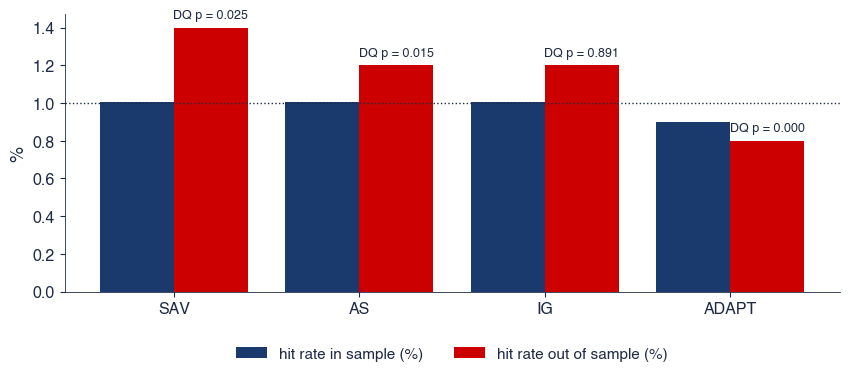

{'SAV': (0.014, (14.433268173141283, 0.025153539575173835)), 'AS': (0.012, (15.81432519155079, 0.014786026506355939)), 'IG': (0.012, (2.2947305834151672, 0.8906962250172065)), 'ADAPT': (0.008, (27.499556211507173, 0.00011670242706587151))}


In [15]:
# Solution
r = b1_caviar_sp500()
print({k: (v['hit_out'], v['dq_out']) for k, v in r.items()})

**Interpretation of the result.** IG passes DQ; SAV and AS are rejected at 5% because of the clustered hits of April 2025.

## B2 [Proposed]: CAViaR for the BET

**Question.** Does the asymmetric slope describe the BET tail? Model: B1.

1. SAV and AS for VaR 1%.
2. GARCH-t on the same window.
3. Hit rate, DQ and pinball out of sample.
4. Interpretation.

**Report:** two coefficient vectors with standard errors, nine numbers, one sentence.

In [ ]:
# Your code here


## B3 [Solved]: replicating Patton, Ziegel and Chen

**Question.** Do we reproduce Table S5 (α = 2.5%) on our data?

1. The ten models.
2. Average FZ0 losses against the paper.
3. DM statistics against GAS-1F.
4. Interpretation.

**Report:** ten pairs of losses, three DM statistics, one sentence.

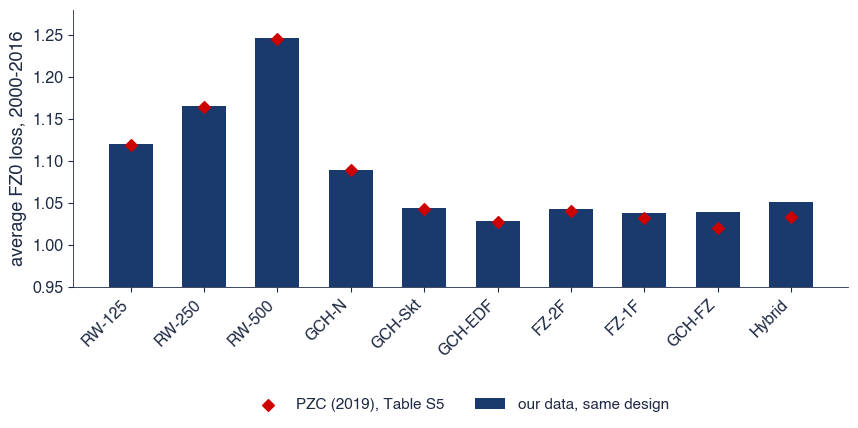

{'RW-125': 1.1202828769660755, 'RW-250': 1.1651830221902255, 'RW-500': 1.2466594085372433, 'GCH-N': 1.0889222629175757, 'GCH-Skt': 1.0441944259608535, 'GCH-EDF': 1.0284213469618242, 'FZ-2F': 1.0435141539946053, 'FZ-1F': 1.0382803492451773, 'GCH-FZ': 1.0399527867824674, 'Hybrid': 1.0513506167488431}
0.5212455183313962 3.872041245720604 1.948118904808893


In [17]:
# Solution
r = b3_pzc()
print(r['loss'])
print(r['dm_fz_edf'], r['dm_rw_fz'], r['dm_n_fz'])

**Interpretation of the result.** The losses match to about two hundredths; the best models cannot be separated.

## B4 [Proposed]: the DAX to 2026

**Question.** Do the semiparametric models keep their advantage on the DAX, 2000–2026? Model: B3.

1. Losses and hit rates of four models.
2. PZC regressions.
3. DM of GAS-1F against GARCH-EDF, whole, before and from 2017.
4. Interpretation.

**Report:** a table, three DM statistics, one sentence.

In [ ]:
# Your code here


## B5 [Solved]: the MCS in stress periods

**Question.** Can the crisis windows separate ES models for Bitcoin and EUR/RON?

1. 90% MCS over the whole out-of-sample period.
2. The same in 2020, 2022, 2025.
3. GAS-1F hits per period.
4. Interpretation.

**Report:** MCS sizes and members, numbers of hits, one sentence.

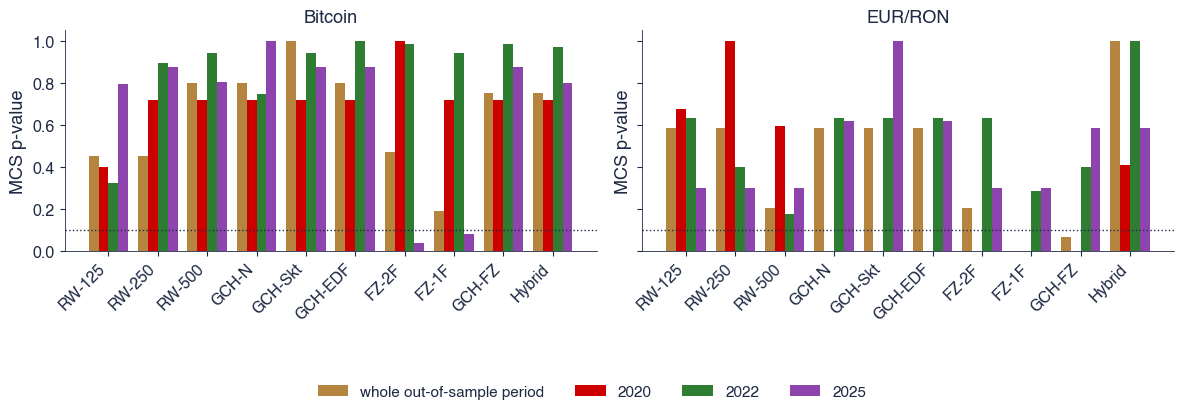

{'btc': (10, {'2020': 10, '2022': 10, '2025': 8}), 'eurron': (8, {'2020': 4, '2022': 10, '2025': 10})}


In [19]:
# Solution
r = b5_mcs()
print({k: (v['size'], {p: q['size'] for p, q in v['periods'].items()}) for k, v in r.items()})

**Interpretation of the result.** A few tail days cannot rank ten models: the MCS keeps almost all of them.

## B6 [Proposed]: 10-day VaR of the DAX

**Question.** How wrong is the square-root-of-time rule for the DAX, and can a backtest tell? Model: B5.

1. Daily 10-day VaR 1% by FHS and by √10 scaling.
2. Median ratios, calm and volatile days.
3. Non-overlapping backtest.
4. Interpretation.

**Report:** three ratios, two hit counts and two p-values, one sentence.

In [ ]:
# Your code here


# Part C: open questions and AI critique

## C1 [Proposed]: a conformal correction for the BET VaR

**Question.** Can adaptive conformal inference repair a Normal GARCH VaR 1% for the BET, and at what cost? Model: B1.

1. A five-line pre-registration.
2. ACI with γ = 0.001, 0.005, 0.02: hit rates, Kupiec and CC p-values, range of α_t.
3. Interpretation: what does ACI fix, and what not?

**Report:** a five-line plan, a table of three rows, a project plan.

In [ ]:
# Your code here


## C2 [Proposed]: audit an AI answer

**Context.** An AI assistant answered:

- (a) VaR 99% is the 99th percentile of returns; for a standard Normal it equals 2.33;
- (b) ES can be compared across models with the mean squared error of the ES forecasts;
- (c) the pinball loss is strictly consistent for the alpha-quantile;
- (d) for a standard Normal, ES 2.5% equals 1.96, the same as the 2.5% quantile;
- (e) estimating the model on more data before a backtest can only make the test more reliable, so the fixed window does not matter;
- (f) the 10-day VaR is always sqrt(10) = 3.16 times the 1-day VaR;
- (g) if several models are in the MCS, they are equally good.

1. For each statement, say whether it is correct; if not, give the correct statement and the correct number.

**Report:** seven verdicts with one line of justification each.

In [ ]:
# Your code here
